## ** NLP-Driven Resume Classification**

### 1. Import The Necessary Library

In [ ]:
import os 
import re 
import nltk
import spacy
import string

import pandas as pd
import seaborn as sns
from matplotlib import pylab
import matplotlib.pyplot as plt
%matplotlib inline
sns.set_style('darkgrid')
sns.set_palette('pastel')
plt.rcParams['figure.figsize']=(12, 8)

from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings('ignore')

In [1]:
#List of files within Resumes Directory
os.listdir('Resumes')

['Peoplesoft_resumes',
 'React_JS_Developer',
 'SQL_Developer',
 'workday_resumes']

### 2. About Dataset

In [2]:
# Creating Extensionwise resume files list 
file_path   = r'Resumes/'
doc_file    = []
pdf_file    = []
docx_file   = []
folder_name = []

for folder in os.listdir(file_path):
    folder_path = os.path.join(file_path, folder)
    for file in os.listdir(folder_path):
        if file.endswith('.doc'):
            doc_file.append(file)
            folder_name.append(folder)
        elif file.endswith('.docx'):
            docx_file.append(file)
            folder_name.append(folder)
        elif file.endswith('.pdf'):
            pdf_file.append(file)
            folder_name.append(folder)

In [3]:
# Number of Files present in folders by extension wise
file_counts={
    ".doc Files ": len(doc_file),
    ".pdf Files": len(pdf_file),
    ".docx Files": len(docx_file)
}

for label, count in file_counts.items():
    print(f'No of {label} = {count}')

print(f'Total Number Of files:- {sum(file_counts.values())}')

No of .doc Files  = 26
No of .pdf Files = 1
No of .docx Files = 52
Total Number Of files:- 79


####  Type of File Format

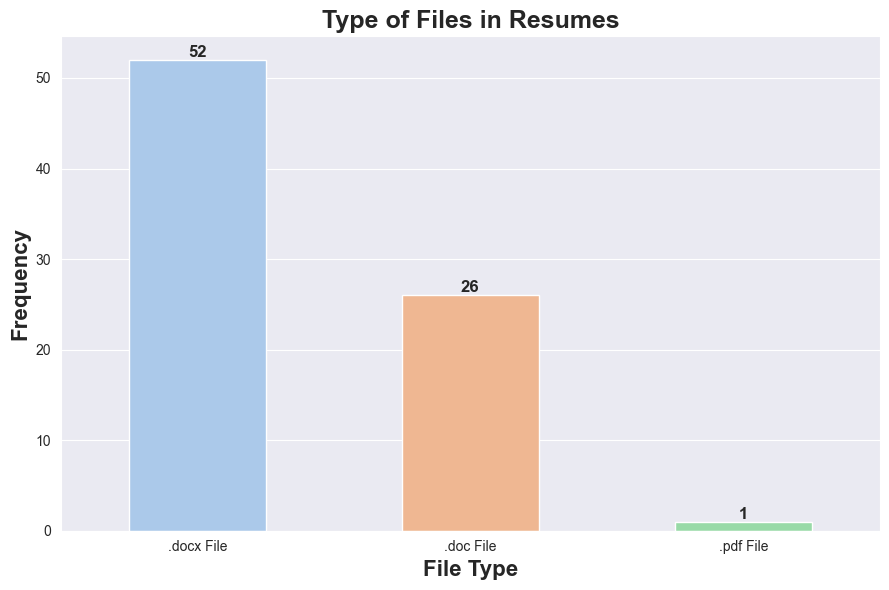

In [4]:
#Bar Plot
file_types = ['.docx File', '.doc File', '.pdf File']
counts = [len(docx_file), len(doc_file), len(pdf_file)]
total_resumes = sum(counts)

fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
colors = sns.color_palette("pastel")
sns.barplot(x=file_types, y=counts, ax=ax, palette=colors, width=0.5)

ax.set_xlabel('File Type', fontsize=16, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=16, fontweight='bold')
ax.set_title('Type of Files in Resumes', fontsize=18, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
fig.savefig('Images/File_Extions_plot.png')

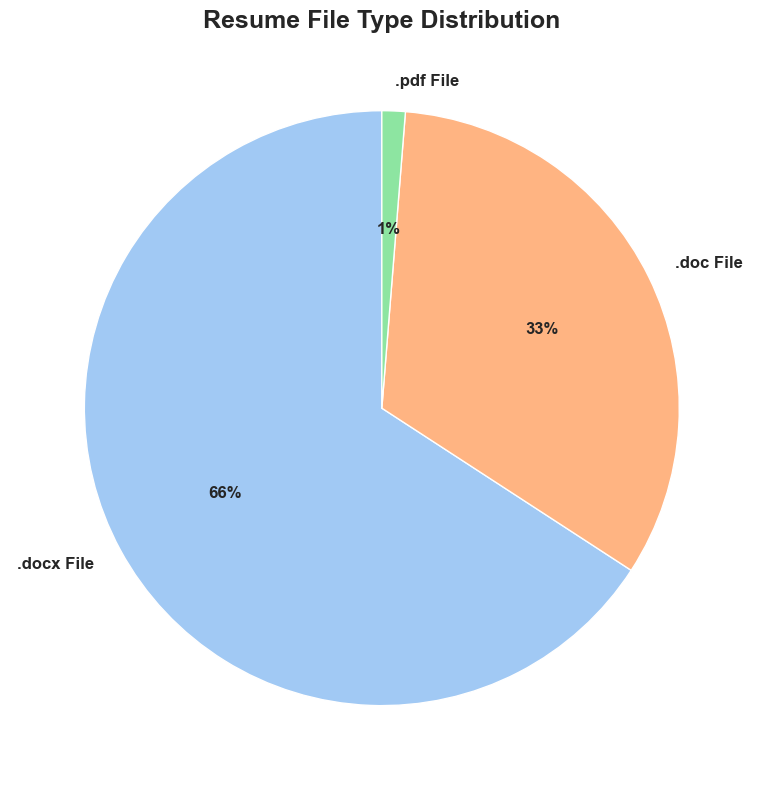

In [5]:
#Pie Plot
fig=plt.figure(figsize=(8, 8), dpi=100)

plt.pie(counts, colors=colors, labels=file_types, autopct='%1.0f%%', 
       startangle=90, textprops={'size':'large', 'fontweight':'bold'})

plt.title('Resume File Type Distribution', fontsize=18, fontweight='bold' )

plt.tight_layout()
fig.savefig('Images/File_extion_Pie.png', dpi=500)
plt.show()

### 3.Reading A Resume File

In [6]:
import docx2txt

def extract_text_from_docx(docx_path):
    txt=docx2txt.process(docx_path)
    if txt:
        return txt.replace('\t', ' ')
    return None
print(extract_text_from_docx('Resumes\React_JS_Developer\React Developer_Haripriya.docx'))

HARIPRIYA BATTINA 

Experience as UI Developer in Reactjs, JavaScript. 

Phone: +91 9908576950 

Gmail: haripriyabattini@gmai.com 

Location: Visakhapatnam 

JOB OBJECTIVE ● Looking for a challenging role to put my experience in various aspects of technology with an objective to be a leading source of information and guidance concerning th

technological requirements. 

● Want to be a part of a reputed organization that allows me to effectively use my 

technical skills in the real world for overall growth of organization and my 

professional career. 

WORK EXPERIENCE EDUCATION 

1. Associate UI Developr 

Company: Blue Yonder, Hyderabad. 

● Work Done On “COPERNICUS” Project. 

● The Main Moto of this project is, it is GTM (Go To Market) Portal which is specially designed for demo teams to shower case Blue Yonder Products and Features for Customers and Partners 

● Technologies: HTML, CSS, React JS. 

● IDE: VS Code. 

● Methodologies: Agile. 

JOB RESPONSIBILITIES: 

● Involved Desi

### 4.Extract the Text from Dataset

In [7]:
import os
import docx2txt
import pdfplumber
import win32com.client

def extract_resumes(folder_path, category_name):

    texts = []
    categories = []

    word = win32com.client.Dispatch("Word.Application")
    word.Visible = False

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            ext = os.path.splitext(file)[1].lower()
            try:
                # .docx
                if ext == ".docx":
                    text = docx2txt.process(file_path)

                # .doc
                elif ext == ".doc":
                    doc = word.Documents.Open(os.path.abspath(file_path), ReadOnly=True)
                    text = doc.Content.Text
                    doc.Close(False)

                #.pdf
                elif ext == ".pdf":
                    text = ""
                    with pdfplumber.open(file_path) as pdf:
                        for page in pdf.pages:
                            text += page.extract_text() or ""
                else:
                    continue
                if text and text.strip():
                    texts.append(text.strip())
                    categories.append(category_name)
            except Exception as e:
                print(f"Skipped {file}: {e}")

    word.Quit()
    df = pd.DataFrame({
        "Raw_Details": texts,
        "Category": categories
    })

    # Remove duplicate resume
    df = df.drop_duplicates(subset="Raw_Details")

    return df


In [8]:
# Extracted Peoplesofts Resumes
data1 = extract_resumes(
    r"Resumes/PeopleSoft_resumes/",
    "PeopleSoft_resumes"
)

print("Total resumes extracted:", data1.shape[0])
data1.head()


Total resumes extracted: 20


,Raw_Details,Category
0,Anubhav Kumar Singh\t\t\n\n\n\nCore Competenci...,PeopleSoft_resumes
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\r7+ years...,PeopleSoft_resumes
2,PeopleSoft Database Administrator\r ...,PeopleSoft_resumes
3,Classification: Internal\n\nClassification: In...,PeopleSoft_resumes
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",PeopleSoft_resumes


In [9]:
# Extracted ReactJS Developer
data2 = extract_resumes(
    r"Resumes/React_JS_Developer/",
    "React_JS_Developer"
)

print("Total resumes extracted:", len(data2))
data2.head()

Total resumes extracted: 24


,Raw_Details,Category
0,Name: Ravali P \n\n\n\n ...,React_JS_Developer
1,SUSOVAN BAG \n\nSeeking a challenging po...,React_JS_Developer
2,Kanumuru Deepak Reddy\n\n\n\n\t\n\n\n\nCAREER ...,React_JS_Developer
3,HARIPRIYA BATTINA \n\nExperience as UI Develop...,React_JS_Developer
4,KAMALAKAR REDDY. A \n\nLinked In: https://www....,React_JS_Developer


In [10]:
# Extracted SQL Developer Resumes
data3 = extract_resumes(
    r"Resumes/SQL_Developer/",
    "SQL_Developer"
)

print("Total resumes extracted:", len(data3))
data3.head()

Total resumes extracted: 14


,Raw_Details,Category
0,ANIL KUMAR MADDUKURI \t\t\n\nSQL & MSBI Devel...,SQL_Developer
1,Aradhana Tripathi\n\n\n\nCurrent Location: Gac...,SQL_Developer
2,BUDDHA VAMSI ...,SQL_Developer
3,KAMBALLA PRADEEP ...,SQL_Developer
4, Hyderabad\rNazeer Basha\rSQL and Power BI D...,SQL_Developer


In [11]:
#Extracted Workdays Resumes
data4 = extract_resumes(
    r"Resumes/workday_resumes/",
    "workday_resumes"
)

print("Total resumes extracted:", len(data4))
data4.head()

Total resumes extracted: 21


,Raw_Details,Category
0,Chinna Subbarayudu M\n\nDOB: 06th March 1994\n...,workday_resumes
1,Name : Gopi Krishna Reddy\n\n\t\t\t\t ...,workday_resumes
2,Hari Krishna M\r\r\rSummary:\rA result oriente...,workday_resumes
3,Harikrishna Akula ...,workday_resumes
4,HIMA.MENDU\r \r\rCareer Objective\rTo continu...,workday_resumes


### 5.Create a DataFrame

In [12]:
data = pd.concat([data1, data2, data3, data4], ignore_index=True)
resume_data=pd.DataFrame(data)

In [13]:
resume_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Raw_Details  79 non-null     object
 1   Category     79 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB


In [14]:
resume_data.head(15)

,Raw_Details,Category
0,Anubhav Kumar Singh\t\t\n\n\n\nCore Competenci...,PeopleSoft_resumes
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\r7+ years...,PeopleSoft_resumes
2,PeopleSoft Database Administrator\r ...,PeopleSoft_resumes
3,Classification: Internal\n\nClassification: In...,PeopleSoft_resumes
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",PeopleSoft_resumes
5,"SIRAZUDDIN M\n\n\tBangalore, INDIA\t\n\n\n\n\n...",PeopleSoft_resumes
6,PEOPLESOFT ADMINISTRATOR\r\r\rSRINIVAS.K \t\t\...,PeopleSoft_resumes
7,PeopleSoft Admin\n\nVARKALA VIKAS\n\n\n\nCaree...,PeopleSoft_resumes
8,Vinod Akkala ...,PeopleSoft_resumes
9,PeopleSoft Admin/PeopleSoft DBA\r\rGanesh Alla...,PeopleSoft_resumes


In [15]:
resume_data['Raw_Details'][4]

'Priyanka Ramadoss\r61/46, MountPleasant, \rCoonoor\rThe Nilgiris- 643102                                                                                            \r\rCareer Objective\r\rTo excel as a software professional by working in a learning and challenging environment and utilize the skills and knowledge through diligence, dedication and ensure maximum contribution to the growth of the organization I work for.\r\rProfile Summary\r\rAn Adept IT professional with 4.11 years (September 2016 - present) of experience as Peoplesoft Admin with Accenture\r\rProfessional Summary\r\rPeopleSoft Administrator (September 2016-Present)\r\rExperience in PeopleSoft Administration for Finance application.\rProficient in creating and configuring PeopleSoft components like Web server, Application server and process schedulers.\rActive monitoring in Non production databases and applications.\rKnowledgeable on PeopleSoft migrations using application designer, data mover and taking compare reports 

#### Save as CSV file

In [16]:
resume_data.to_csv('Datasets/Raw_resume_data.csv', index=False)

### **Exploratory Data Analysis**

### 6. Data Understanding

In [17]:
resume_data=pd.read_csv('Datasets/Raw_resume_data.csv')
resume_data.head()

,Raw_Details,Category
0,Anubhav Kumar Singh\t\t\n\n\n\nCore Competenci...,PeopleSoft_resumes
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\r7+ years...,PeopleSoft_resumes
2,PeopleSoft Database Administrator\r ...,PeopleSoft_resumes
3,Classification: Internal\n\nClassification: In...,PeopleSoft_resumes
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",PeopleSoft_resumes


In [18]:
label=resume_data.Category.value_counts().index
label

Index(['React_JS_Developer', 'workday_resumes', 'PeopleSoft_resumes',
       'SQL_Developer'],
      dtype='object', name='Category')

In [19]:
# Exploring Categories - getting value counts of each category
resume_count=resume_data.Category.value_counts()
resume_count

Category
React_JS_Developer    24
workday_resumes       21
PeopleSoft_resumes    20
SQL_Developer         14
Name: count, dtype: int64

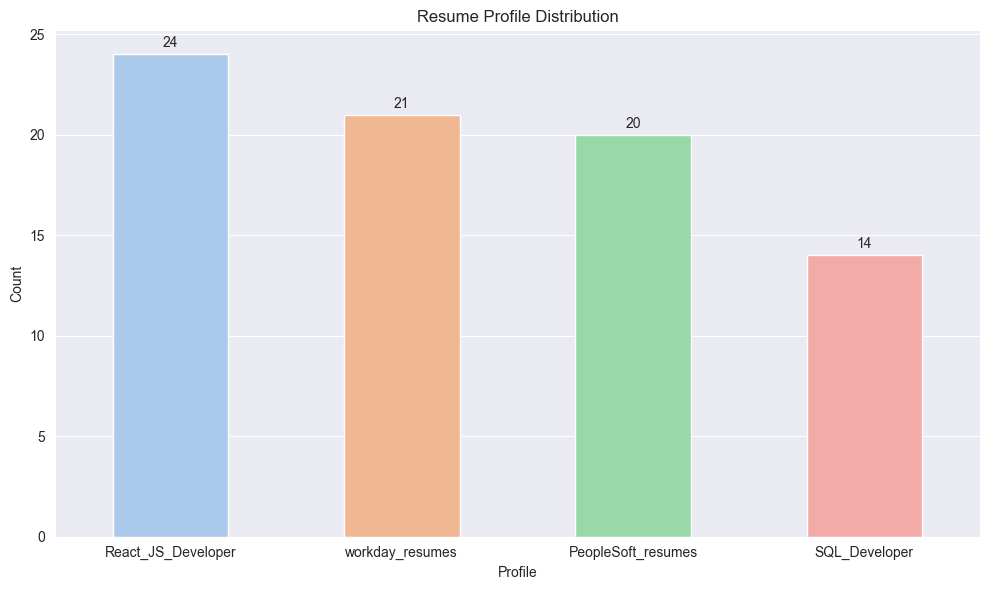

In [20]:
#Creating The Bar plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=resume_count.index,
    y=resume_count.values,
    width=0.5, palette=colors)

plt.xticks()
plt.xlabel("Profile")
plt.ylabel("Count")
plt.title("Resume Profile Distribution")

for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()
fig.savefig('Images/Profile_Distrition_plot.png')


##### A] No. of Words in each Resume 

In [21]:
resume_data['Word_Count']=resume_data['Raw_Details'].apply(lambda x: len(str(x).split(" ")))
resume_data[['Raw_Details', 'Word_Count']].head()

,Raw_Details,Word_Count
0,Anubhav Kumar Singh\t\t\n\n\n\nCore Competenci...,1023
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\r7+ years...,1431
2,PeopleSoft Database Administrator\r ...,1346
3,Classification: Internal\n\nClassification: In...,558
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",667


##### B] No of Characters

In [22]:
resume_data['Char_Count']=resume_data['Raw_Details'].str.len()
resume_data[['Raw_Details', 'Char_Count']].head()

,Raw_Details,Char_Count
0,Anubhav Kumar Singh\t\t\n\n\n\nCore Competenci...,8010
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\r7+ years...,8035
2,PeopleSoft Database Administrator\r ...,6766
3,Classification: Internal\n\nClassification: In...,4917
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",5071


##### C] No. of Stopwords

In [23]:
from nltk.corpus import stopwords
stop=stopwords.words('english')
resume_data['Stopwords']=resume_data['Raw_Details'].apply(lambda x: len([x for x in x.split() if x in stop]))
resume_data[['Raw_Details', 'Stopwords']].head()

,Raw_Details,Stopwords
0,Anubhav Kumar Singh\t\t\n\n\n\nCore Competenci...,190
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\r7+ years...,186
2,PeopleSoft Database Administrator\r ...,177
3,Classification: Internal\n\nClassification: In...,114
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",123


##### D]No. Of Numerics

In [24]:
resume_data['Numerics']=resume_data['Raw_Details'].apply(lambda x: len([x for x in x.split() if x.isdigit()]))
resume_data[['Raw_Details','Numerics']].head()

,Raw_Details,Numerics
0,Anubhav Kumar Singh\t\t\n\n\n\nCore Competenci...,4
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\r7+ years...,6
2,PeopleSoft Database Administrator\r ...,4
3,Classification: Internal\n\nClassification: In...,7
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",5


### 7. Text Pre-processing

In [25]:
# Using Regular Expressions cleaning Resumes(Removing URLs, hastags, special Letters, html tags, punctuations)
def preprocess(sentence):
    sentence=str(sentence)
    sentence=sentence.lower()
    sentence=sentence.replace('{html}', "")
    cleanr=re.compile('<.*?>')
    cleantext=re.sub(cleanr, '', sentence)
    rem_url=re.sub(r'hhtp\S+','', cleantext)
    rem_num=re.sub('[0-9]+', '',rem_url)
    tokenizer=RegexpTokenizer(r'\w+')
    tokens=tokenizer.tokenize(rem_num)
    filtered_words=[w for w in tokens if len(w) > 2 if not w in stopwords.words('english')]
    return " ".join(filtered_words)

In [26]:
resume_data=pd.read_csv('Datasets/Raw_resume_data.csv')
resume_data['Resume_Details']=resume_data.Raw_Details.apply(lambda x: preprocess(x))

In [27]:
resume_data

,Raw_Details,Category,Resume_Details
0,Anubhav Kumar Singh\t\t\n\n\n\nCore Competenci...,PeopleSoft_resumes,anubhav kumar singh core competencies scriptin...
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\r7+ years...,PeopleSoft_resumes,profile summary years experience implementing ...
2,PeopleSoft Database Administrator\r ...,PeopleSoft_resumes,peoplesoft database administrator gangareddy p...
3,Classification: Internal\n\nClassification: In...,PeopleSoft_resumes,classification internal classification interna...
4,"Priyanka Ramadoss\r61/46, MountPleasant, \rCoo...",PeopleSoft_resumes,priyanka ramadoss mountpleasant coonoor nilgir...
...,...,...,...
74,Workday Integration Consultant\r\rName ...,workday_resumes,workday integration consultant name sri krishn...
75,Srikanth (WORKDAY hCM Consultant)\t ...,workday_resumes,srikanth workday hcm consultant seeking suitab...
76,WORKDAY | HCM | FCM\n\nName \t\t: Kumar S.S\n\...,workday_resumes,workday hcm fcm name kumar role workday consul...
77,Venkateswarlu.B\t\t\t\t\t\t\t\tWorkday Consult...,workday_resumes,venkateswarlu workday consultant years experie...


#### Save clean Data in new CSV File

In [28]:
resume_data.drop(['Raw_Details'], axis=1, inplace=True)
resume_data

,Category,Resume_Details
0,PeopleSoft_resumes,anubhav kumar singh core competencies scriptin...
1,PeopleSoft_resumes,profile summary years experience implementing ...
2,PeopleSoft_resumes,peoplesoft database administrator gangareddy p...
3,PeopleSoft_resumes,classification internal classification interna...
4,PeopleSoft_resumes,priyanka ramadoss mountpleasant coonoor nilgir...
...,...,...
74,workday_resumes,workday integration consultant name sri krishn...
75,workday_resumes,srikanth workday hcm consultant seeking suitab...
76,workday_resumes,workday hcm fcm name kumar role workday consul...
77,workday_resumes,venkateswarlu workday consultant years experie...


In [29]:
# Clean Resume
resume_data.to_csv(r'Datasets/Clean_Resume.csv', index=False)


In [30]:
# Representation of Clean Dataset
resume_data=pd.read_csv('Datasets/Clean_Resume.csv')
resume_data

,Category,Resume_Details
0,PeopleSoft_resumes,anubhav kumar singh core competencies scriptin...
1,PeopleSoft_resumes,profile summary years experience implementing ...
2,PeopleSoft_resumes,peoplesoft database administrator gangareddy p...
3,PeopleSoft_resumes,classification internal classification interna...
4,PeopleSoft_resumes,priyanka ramadoss mountpleasant coonoor nilgir...
...,...,...
74,workday_resumes,workday integration consultant name sri krishn...
75,workday_resumes,srikanth workday hcm consultant seeking suitab...
76,workday_resumes,workday hcm fcm name kumar role workday consul...
77,workday_resumes,venkateswarlu workday consultant years experie...


In [31]:
resume_data.Resume_Details[2]

'peoplesoft database administrator gangareddy professional objective work professional challenging environment best utilizing talent keeping abreast latest technical advancement field peoplesoft application dba derive utmost job satisfaction knowledge field become successful oracle peoplesoft application dba activities professional summary years experience peoplesoft applications admin dba experience creating configuring application server domains created multiple server domains separate host systems access one database effective strategy performance tuning experience application server administration ensured system availability implementing failover spreading multiple domains across multiple hosts peoplesoft server administration expertise installation configuration setup management database peoplesoft internet architecture pia environment related processing objects extensive experience applying tax updates patches fixes bundles maintenance packs experienced peoplesoft applications ad

In [32]:
resume_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Category        79 non-null     object
 1   Resume_Details  79 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB


In [33]:
resume_data.describe(include='all')

,Category,Resume_Details
count,79,79
unique,4,77
top,React_JS_Developer,mareedu lokesh babu professional overview arou...
freq,24,2


In [34]:
#Checking if dataset has any null values or not
resume_data.isnull().sum()

Category          0
Resume_Details    0
dtype: int64

In [35]:
resume_data.duplicated().sum()

2

#### N-grams
- Group of N consecutive words or characters taken from a piece of text.

In [36]:
def generate_ngrams(text, n):
    tokens = text.split()
    ngrams = [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
    return ngrams

text = resume_data['Resume_Details'][2] 

unigrams = generate_ngrams(text, 1)[:15]
bigrams = generate_ngrams(text, 2)[:15]
trigrams = generate_ngrams(text, 3)[:15]


In [37]:
unigrams

[('peoplesoft',),
 ('database',),
 ('administrator',),
 ('gangareddy',),
 ('professional',),
 ('objective',),
 ('work',),
 ('professional',),
 ('challenging',),
 ('environment',),
 ('best',),
 ('utilizing',),
 ('talent',),
 ('keeping',),
 ('abreast',)]

In [38]:
bigrams

[('peoplesoft', 'database'),
 ('database', 'administrator'),
 ('administrator', 'gangareddy'),
 ('gangareddy', 'professional'),
 ('professional', 'objective'),
 ('objective', 'work'),
 ('work', 'professional'),
 ('professional', 'challenging'),
 ('challenging', 'environment'),
 ('environment', 'best'),
 ('best', 'utilizing'),
 ('utilizing', 'talent'),
 ('talent', 'keeping'),
 ('keeping', 'abreast'),
 ('abreast', 'latest')]

In [39]:
resume_data['Resume_Details']

0     anubhav kumar singh core competencies scriptin...
1     profile summary years experience implementing ...
2     peoplesoft database administrator gangareddy p...
3     classification internal classification interna...
4     priyanka ramadoss mountpleasant coonoor nilgir...
                            ...                        
74    workday integration consultant name sri krishn...
75    srikanth workday hcm consultant seeking suitab...
76    workday hcm fcm name kumar role workday consul...
77    venkateswarlu workday consultant years experie...
78    vinay kumar workday functional consultant expe...
Name: Resume_Details, Length: 79, dtype: object

#### CountVectorizer


In [40]:
vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2))
X = vectorizer.fit_transform(resume_data['Resume_Details'])

# total frequency of each n-gram
frequencies = X.sum(axis=0).A1

# Get n-gram words
terms = vectorizer.get_feature_names_out()
df_ngram = pd.DataFrame({
    "Ngram": terms,
    "Frequency": frequencies})

# Sort by highest frequency
df_ngram = df_ngram.sort_values(by="Frequency", ascending=False).reset_index(drop=True)

df_ngram.head(20)


,Ngram,Frequency
0,experience,596
1,peoplesoft,453
2,workday,430
3,application,418
4,using,395
5,server,358
6,data,332
7,reports,326
8,project,325
9,sql,279


In [41]:
df_ngram.columns

Index(['Ngram', 'Frequency'], dtype='object')

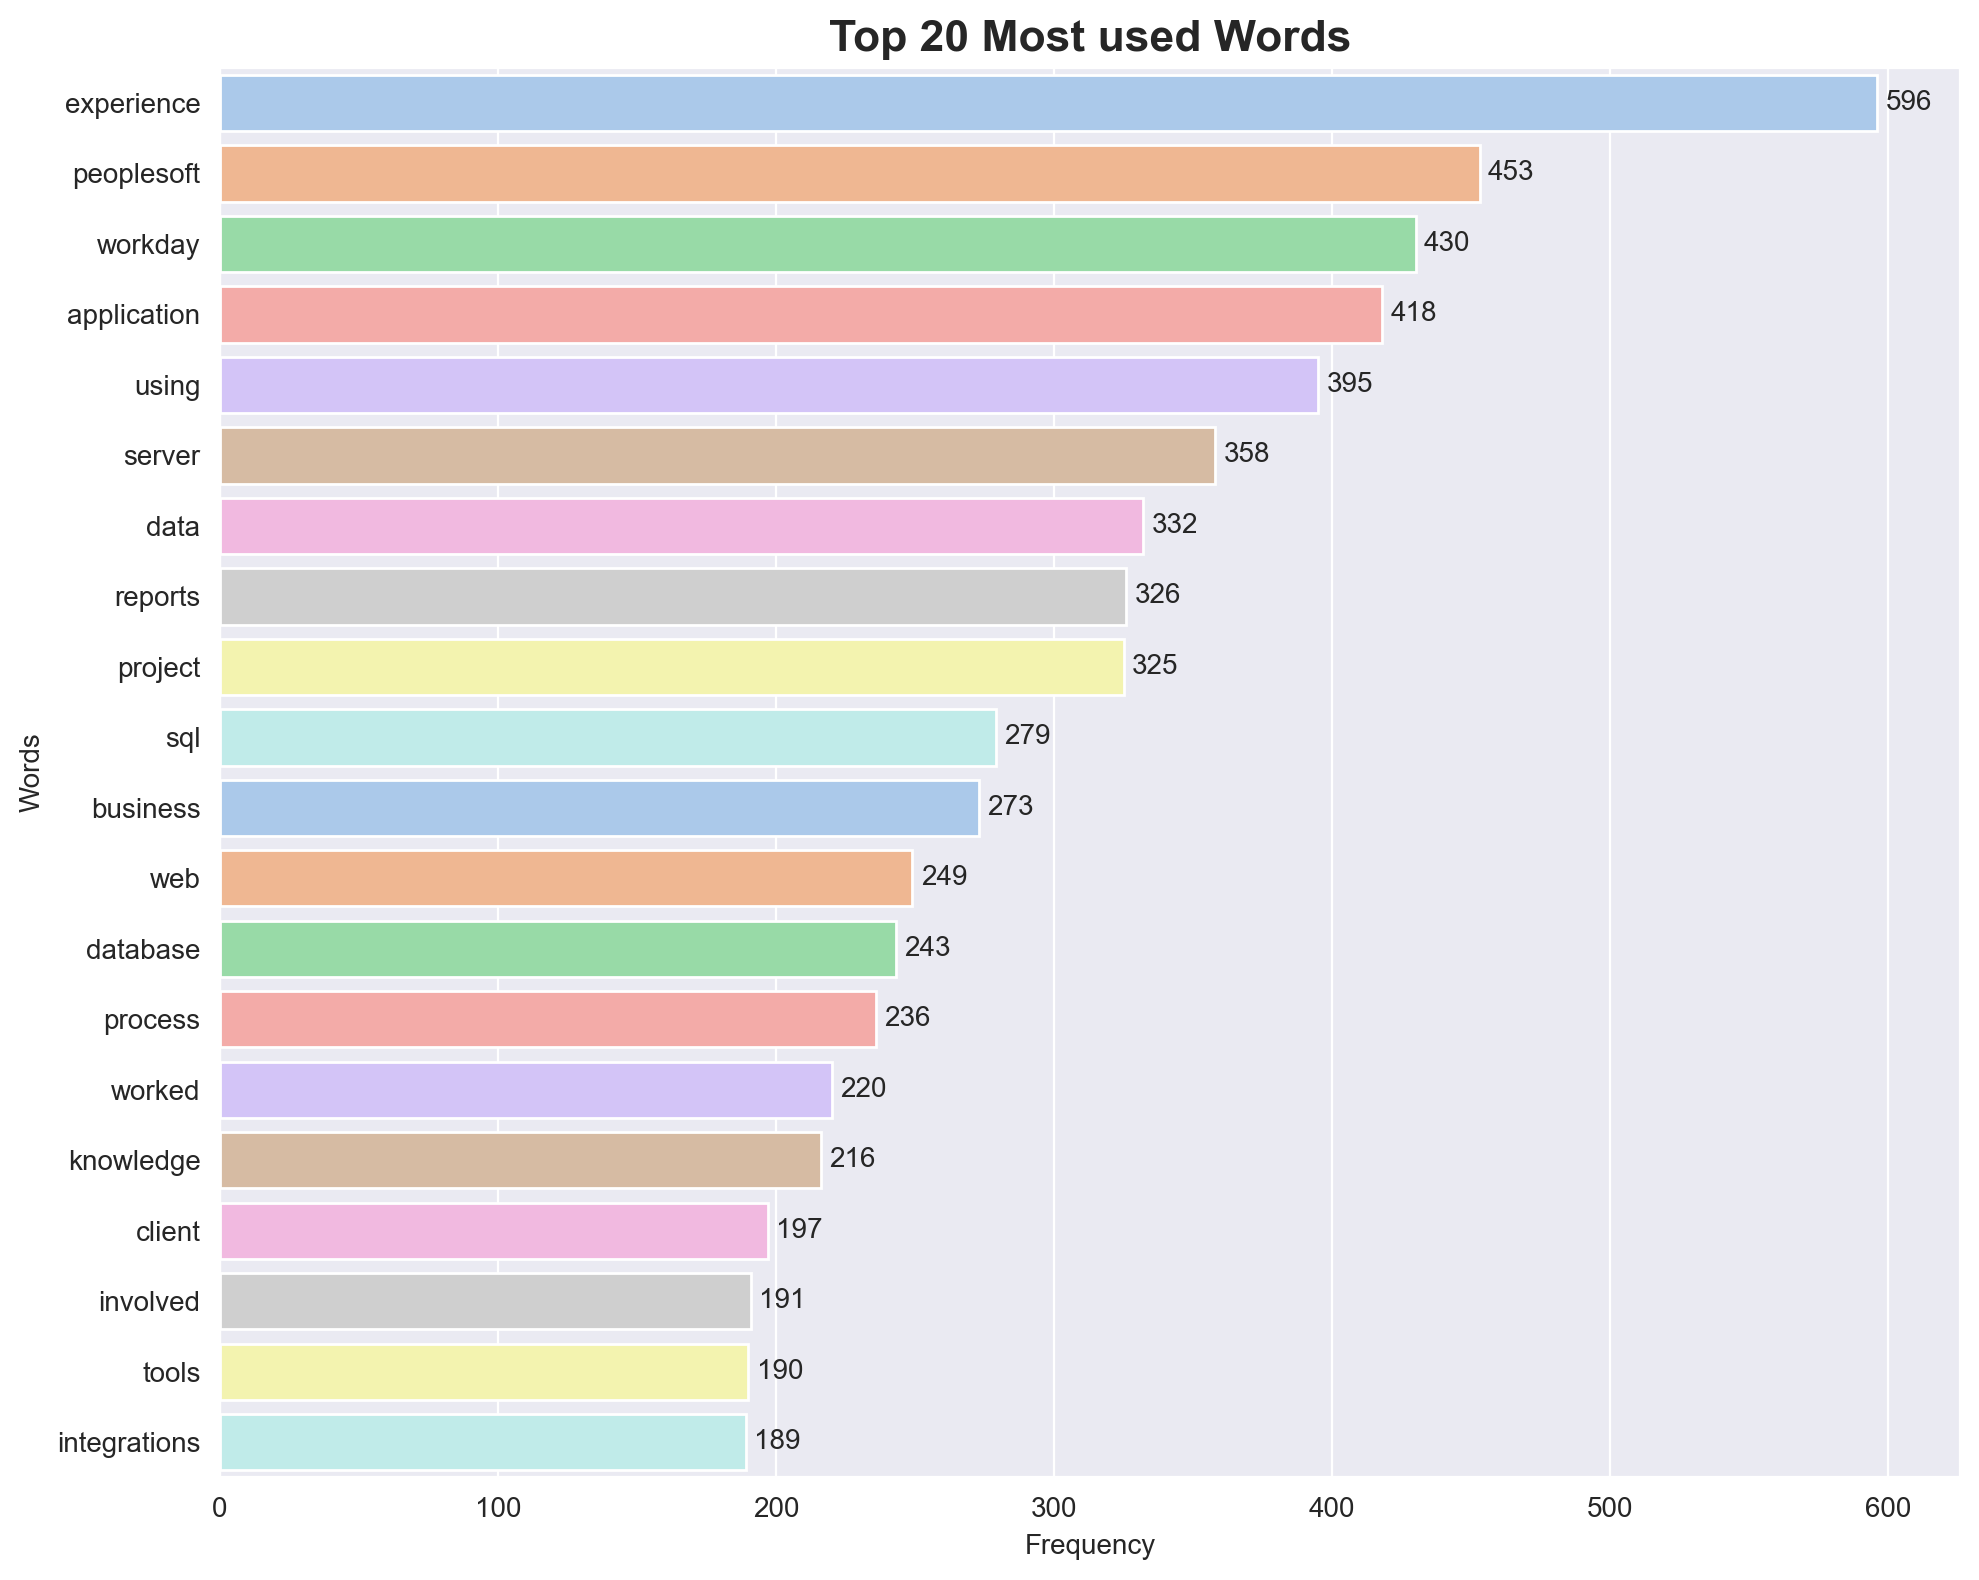

In [42]:
plt.figure(figsize=(10, 8), dpi=200)
top20=df_ngram.head(20)
ax=sns.barplot(
    x='Frequency', y='Ngram',
    data=top20, palette=colors)

plt.title('Top 20 Most used Words', fontsize=16, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Words')

for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
fig.savefig('Images/Top_20_Words.png')

plt.show()

#### Named Entity Recognition(NER)

In [43]:
oneSetOfStopWords=set(stopwords.words('english')+ ['``',"''"])
resume_data.Resume_Details[5]
totalWords = []
Sentences=resume_data['Resume_Details'].values
cleanedSent= ""
for records in Sentences:
    cleanedtext=preprocess(records)
    cleanedSent +=cleanedtext
    requiredwords = nltk.word_tokenize(cleanedtext)
    #remove stopwords and punctuation
    for word in requiredwords:
        if word not in oneSetOfStopWords and word not in string.punctuation:
            totalWords.append(word)
#calculate  word freq
wordfreqdist= nltk.FreqDist(totalWords)
mostcommon = wordfreqdist.most_common(50)
print(mostcommon)

[('experience', 596), ('peoplesoft', 453), ('workday', 430), ('application', 418), ('using', 395), ('server', 358), ('data', 332), ('reports', 326), ('project', 325), ('sql', 279), ('business', 273), ('web', 249), ('database', 243), ('process', 236), ('worked', 220), ('knowledge', 216), ('client', 197), ('system', 192), ('involved', 191), ('tools', 190), ('integrations', 189), ('integration', 183), ('hcm', 182), ('like', 180), ('support', 178), ('skills', 169), ('good', 169), ('development', 168), ('team', 166), ('creating', 164), ('working', 162), ('people', 160), ('services', 157), ('technical', 156), ('report', 155), ('design', 154), ('servers', 152), ('testing', 150), ('created', 150), ('react', 148), ('responsibilities', 147), ('various', 146), ('oracle', 142), ('role', 142), ('environment', 139), ('developer', 137), ('management', 136), ('security', 134), ('eib', 134), ('production', 133)]


#### Parts Of Speech Tagging


In [44]:
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_lg")   #A large Model to process text
sample_text = cleanedSent[:3000]
processed_doc = nlp(sample_text)

displacy.render(processed_doc, style="ent", jupyter=True)

In [45]:
for token in processed_doc[:30]:
    print(token, token.pos_) #represent grammetical role of word

anubhav PROPN
kumar PROPN
singh PROPN
core PROPN
competencies NOUN
scripting VERB
shell NOUN
scripting NOUN
application NOUN
peoplesoft PROPN
hcm PROPN
financials PROPN
operating NOUN
system NOUN
linux PROPN
windows PROPN
web NOUN
app NOUN
servers NOUN
weblogic PROPN
tuxedo PROPN
rdbms PROPN
oracle PROPN
repository PROPN
github PROPN
core PROPN
competencies NOUN
scripting VERB
shell NOUN
scripting NOUN


#### Counting all Nouns and verbs present in Tokens of words


In [46]:
sample_text =cleanedSent
processed_doc=nlp(sample_text)
nouns_verbs=[token.text for token in processed_doc
             if token.pos_ in('NOUN', 'VERB')]

print(nouns_verbs[:250])

['competencies', 'scripting', 'shell', 'scripting', 'application', 'operating', 'system', 'web', 'app', 'servers', 'competencies', 'scripting', 'shell', 'scripting', 'application', 'operating', 'system', 'web', 'app', 'servers', 'work', 'environment', 'challenging', 'assignments', 'yield', 'benefits', 'job', 'satisfaction', 'paced', 'growth', 'experience', 'role', 'system', 'admin', 'skills', 'shell', 'scripting', 'managing', 'fscm', 'production', 'environments', 'support', 'environments', 'installed', 'windows', 'involved', 'day', 'day', 'activities', 'project', 'migration', 'database', 'refresh', 'system', 'admin', 'changes', 'tax', 'updates', 'troubleshooting', 'servers', 'application', 'servers', 'web', 'servers', 'process', 'scheduler', 'servers', 'applying', 'tuxedo', 'weblogic', 'middleware', 'cpu', 'patches', 'applications', 'working', 'shell', 'scripting', 'used', 'integration', 'method', 'exchange', 'files', 'systems', 'installation', 'troubleshooting', 'tier', 'setup', 'requ

#### Counting all Nouns and verbs present in Tokens of words

In [47]:
from collections import Counter

word_counts =Counter(nouns_verbs)
words_freq=word_counts.most_common()
wd_df=pd.DataFrame(words_freq, columns=['Words', 'Count'])
wd_df.head(20)

,Words,Count
0,experience,543
1,application,411
2,using,394
3,reports,326
4,workday,312
5,data,309
6,project,300
7,business,262
8,web,249
9,database,240


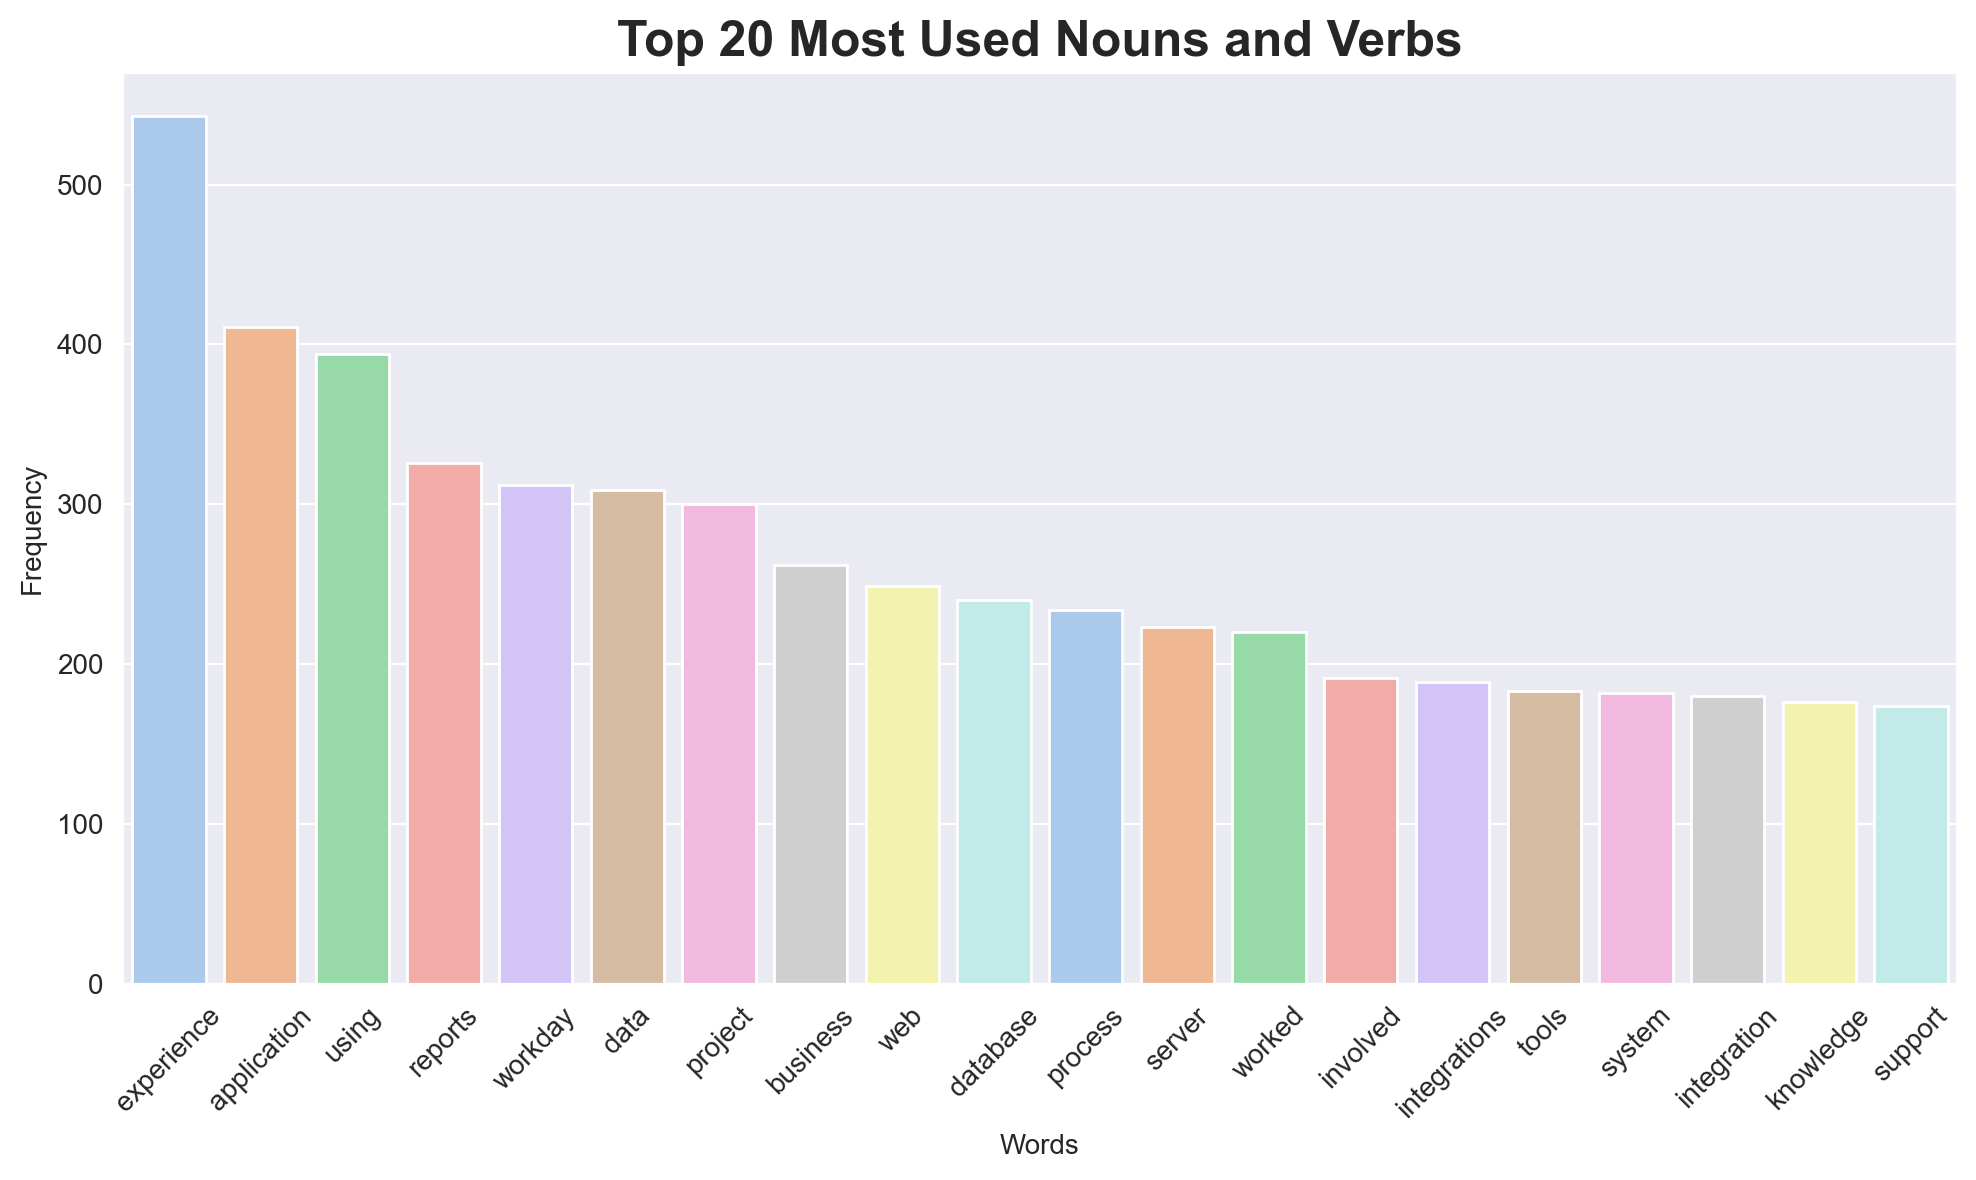

In [48]:
# Select top 20 words
top20 = wd_df.head(20)

plt.figure(figsize=(10,6), dpi=200)

sns.barplot(
    x='Words', y='Count', 
    data=top20, palette=colors)

plt.title('Top 20 Most Used Nouns and Verbs', fontsize=18, fontweight='bold')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('Images/Top_20_Noun-Verbs.png')


### Extract Technical Skills

In [49]:
from spacy.matcher import PhraseMatcher
skills_list = ['python', 'java', 'sql', 'machine learning',
               'deep learning', 'tensorflow', 'pandas',
               'numpy', 'aws', 'docker', 'power bi']

nlp = spacy.load("en_core_web_sm")
matcher = PhraseMatcher(nlp.vocab)

patterns = [nlp(skill) for skill in skills_list]
matcher.add("SKILLS", patterns)

doc = nlp(cleanedSent)
matches = matcher(doc)

extracted_skills = [doc[start:end].text for match_id, start, end in matches]

print(set(extracted_skills))


{'numpy', 'aws', 'sql', 'docker', 'java', 'python', 'pandas'}


#### WordCloud for Most used Nouns and verbs in Resumes

<Figure size 1200x800 with 0 Axes>

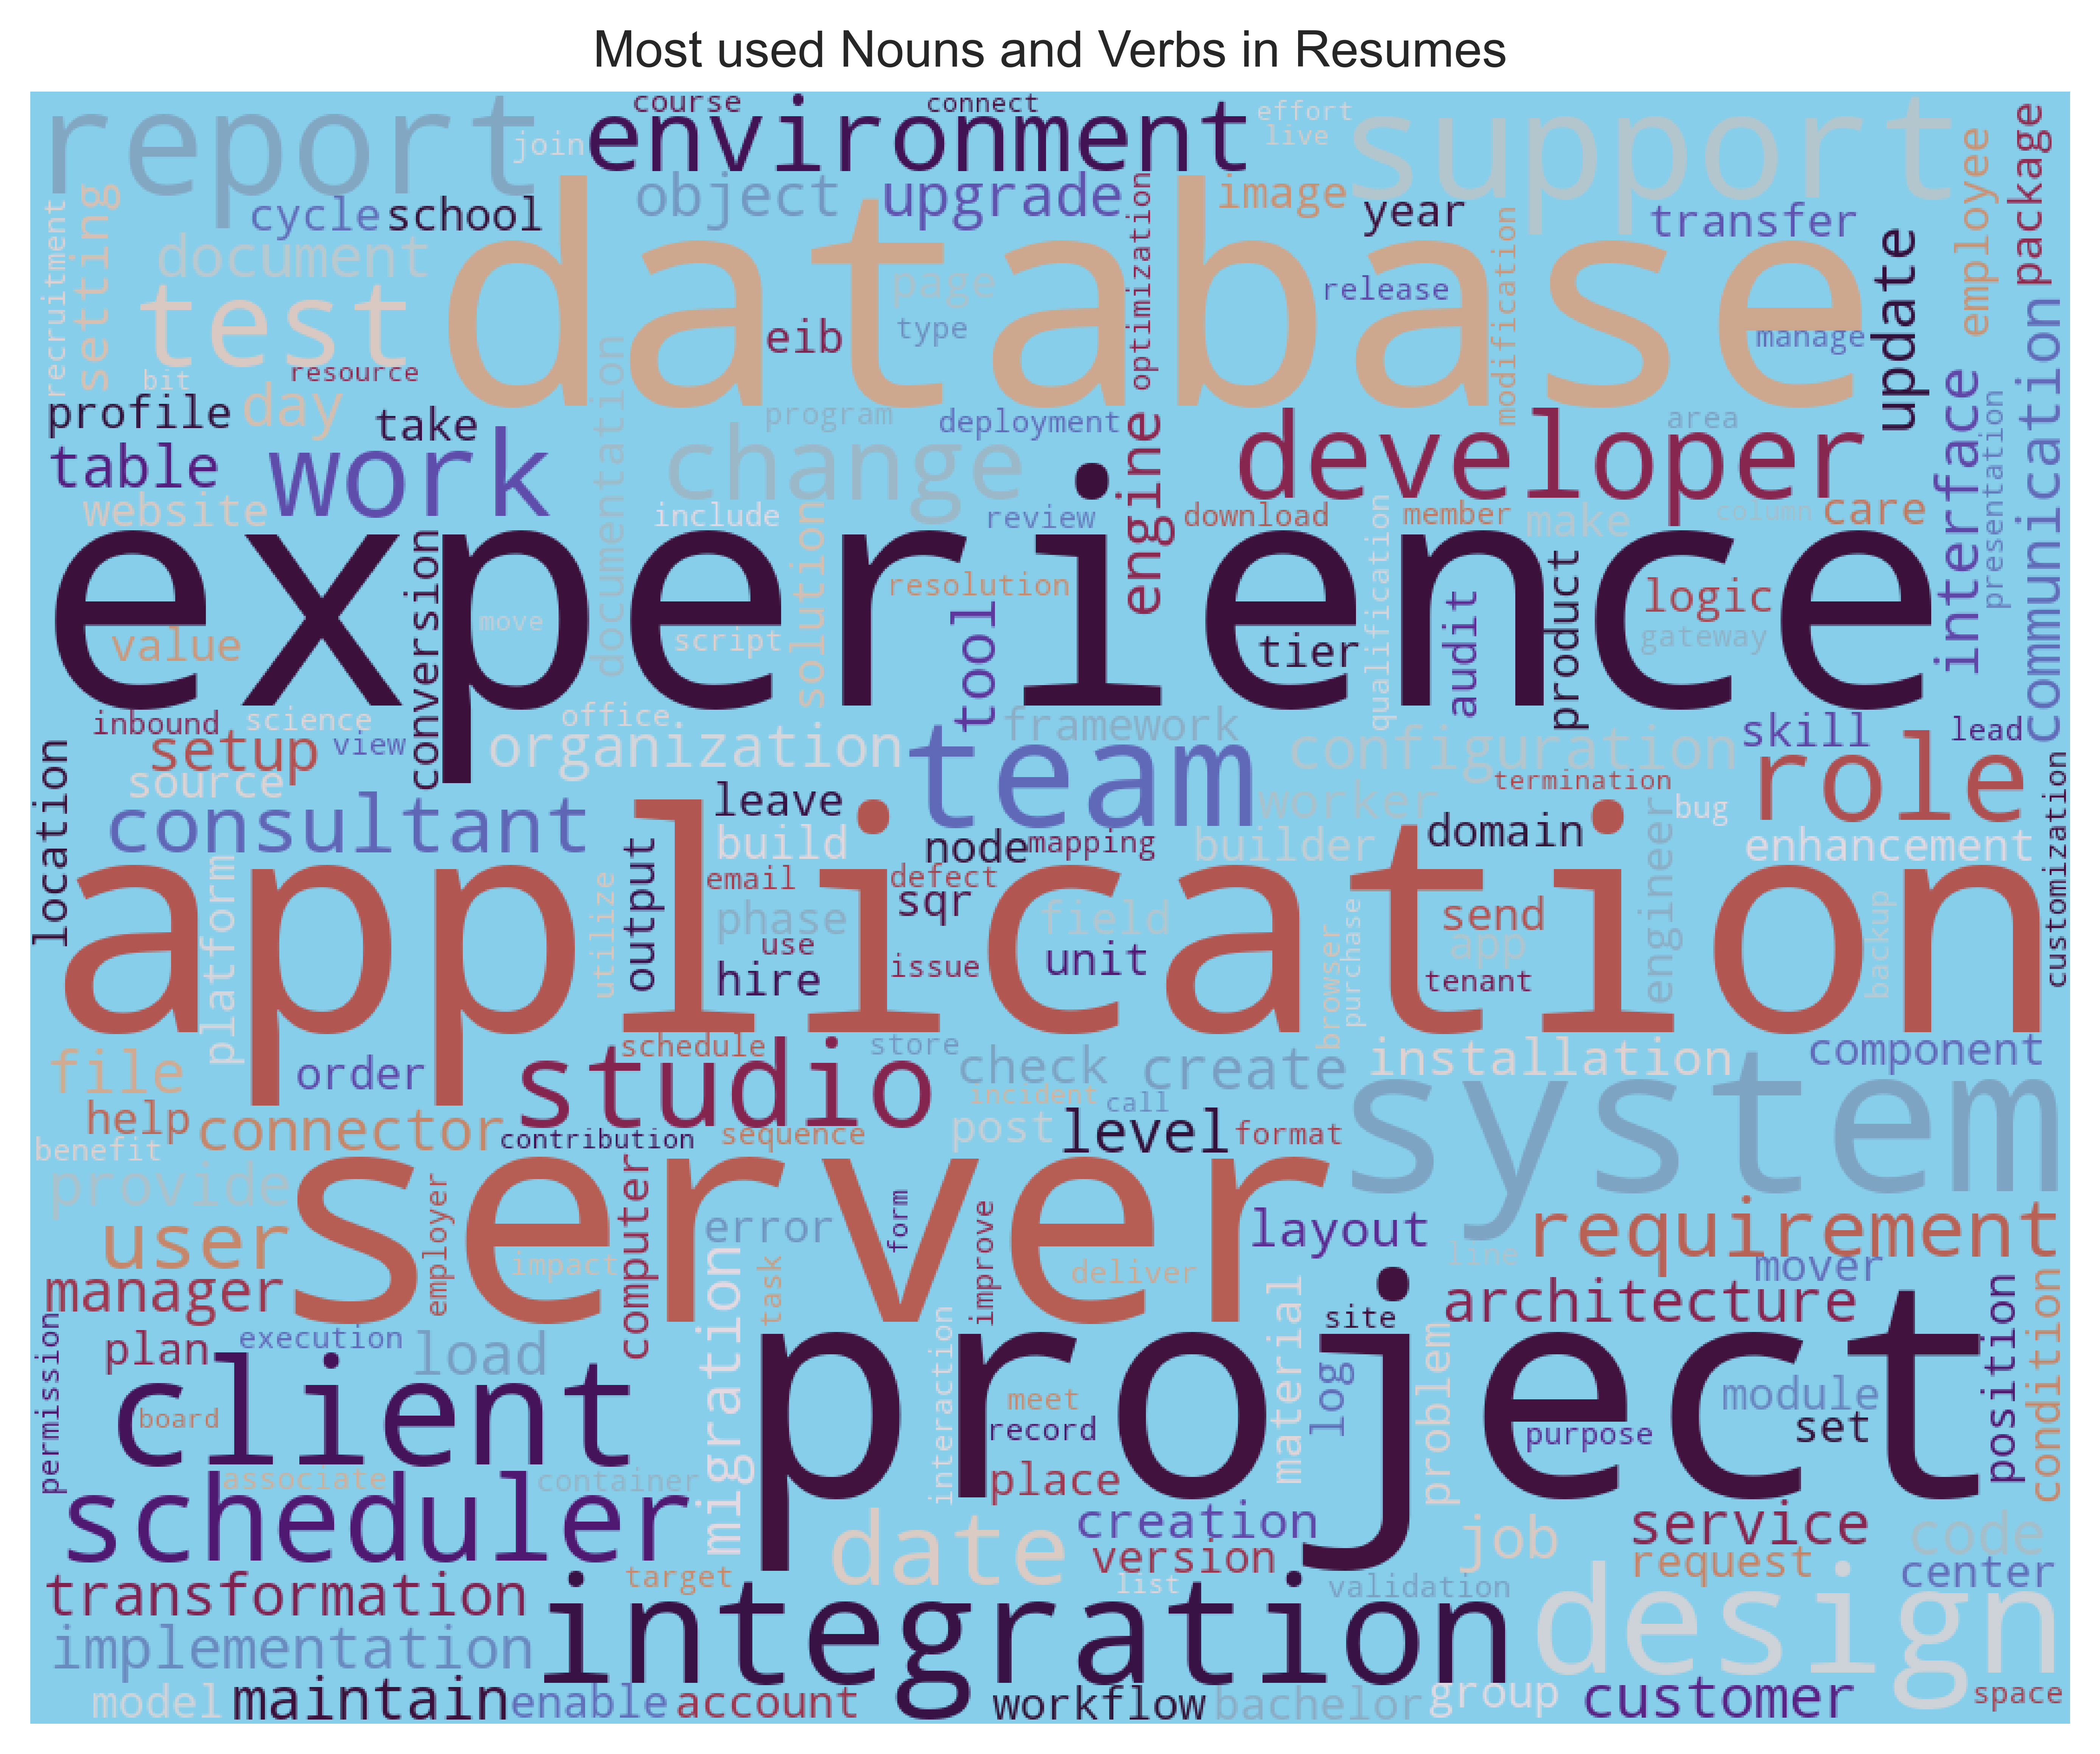

In [50]:
text = " ".join(cat for cat in wd_df.Words)  #creating text variable
word_cloud =WordCloud(width=1000, height=800, random_state=10, background_color='SkyBlue',
                     colormap='twilight_shifted_r', collocations=False, stopwords=STOPWORDS).generate(text)
plt.figure(figsize=(10, 7), dpi=800) 
plt.title('Most used Nouns and Verbs in Resumes')
plt.imshow(word_cloud)
plt.axis('off')

word_cloud.to_file('Images/Word_Cloud.png')
plt.show()

### Data Transformation

In [51]:
resume_data.describe()

,Category,Resume_Details
count,79,79
unique,4,77
top,React_JS_Developer,mareedu lokesh babu professional overview arou...
freq,24,2


In [52]:
resume_data.isnull().sum()

Category          0
Resume_Details    0
dtype: int64

In [53]:
x=resume_data['Resume_Details']
y=resume_data['Category']

#### Data Spliting

In [54]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(x, y, random_state=45, test_size=0.25, stratify=y)
x_train.shape, x_test.shape

((59,), (20,))

#### Vectorization (using TfidfVectorizer)

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(sublinear_tf =True, max_features=5000, stop_words='english')


In [56]:
x_train=tfidf.fit_transform(x_train)
x_test=tfidf.transform(x_test)

In [57]:
x_train.shape, x_test.shape

((59, 3633), (20, 3633))

In [58]:
print(x_train), print(x_test )

  (0, 2607)	0.03996852057228459
  (0, 96)	0.044024307948737254
  (0, 3170)	0.022578423324895805
  (0, 3622)	0.011826528964049772
  (0, 1153)	0.022068753189217378
  (0, 2340)	0.07143671982697253
  (0, 3247)	0.032463827569703986
  (0, 686)	0.040226782978913925
  (0, 795)	0.03149316745919493
  (0, 173)	0.05328381123690284
  (0, 3440)	0.029836866078836555
  (0, 2337)	0.062411270352447985
  (0, 3325)	0.05084091293072941
  (0, 893)	0.03149316745919493
  (0, 1763)	0.024819299016244186
  (0, 2341)	0.02792541845639351
  (0, 1824)	0.022578423324895805
  (0, 903)	0.03732696115729083
  (0, 2339)	0.03709089363337074
  (0, 1073)	0.06856492340118645
  (0, 2267)	0.06328885669201802
  (0, 2898)	0.028675507664291118
  (0, 1227)	0.04513082690232148
  (0, 1787)	0.048738308207362475
  (0, 3614)	0.03732696115729083
  :	:
  (58, 2440)	0.045259856869379854
  (58, 1784)	0.07663159905093718
  (58, 2206)	0.045259856869379854
  (58, 48)	0.045259856869379854
  (58, 1813)	0.045259856869379854
  (58, 648)	0.04525985

(None, None)

In [59]:
print(y_train), print(y_test)

13    PeopleSoft_resumes
28    React_JS_Developer
12    PeopleSoft_resumes
70       workday_resumes
56         SQL_Developer
54         SQL_Developer
25    React_JS_Developer
1     PeopleSoft_resumes
30    React_JS_Developer
2     PeopleSoft_resumes
31    React_JS_Developer
55         SQL_Developer
21    React_JS_Developer
33    React_JS_Developer
75       workday_resumes
22    React_JS_Developer
46         SQL_Developer
40    React_JS_Developer
16    PeopleSoft_resumes
35    React_JS_Developer
38    React_JS_Developer
60       workday_resumes
14    PeopleSoft_resumes
17    PeopleSoft_resumes
8     PeopleSoft_resumes
45         SQL_Developer
59       workday_resumes
72       workday_resumes
68       workday_resumes
36    React_JS_Developer
71       workday_resumes
20    React_JS_Developer
51         SQL_Developer
66       workday_resumes
41    React_JS_Developer
78       workday_resumes
50         SQL_Developer
62       workday_resumes
19    PeopleSoft_resumes
10    PeopleSoft_resumes


(None, None)

In [60]:
import joblib
import pickle 
pickle.dump(tfidf, open('Models/tfidf.pkl', 'wb'))


### Model Building

#### 1] Logistic Regression

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
lr_train_pred=lr.predict(x_train)
lr_test_pred=lr.predict(x_test)

lr_train_acc=accuracy_score(y_train, lr_train_pred)
lr_test_acc=accuracy_score(y_test, lr_test_pred)

print('Logistic Regression Classifier:')
print('Training Accuracy:', lr_train_acc)
print('Testing Accuracy:', lr_test_acc) 

print('classification_report:\n', classification_report(y_test, lr_test_pred))
pickle.dump(lr, open('Models/logistic_model.pkl', 'wb'))   

Logistic Regression Classifier:
Training Accuracy: 1.0
Testing Accuracy: 0.95
classification_report:
                     precision    recall  f1-score   support

PeopleSoft_resumes       1.00      0.80      0.89         5
React_JS_Developer       0.86      1.00      0.92         6
     SQL_Developer       1.00      1.00      1.00         4
   workday_resumes       1.00      1.00      1.00         5

          accuracy                           0.95        20
         macro avg       0.96      0.95      0.95        20
      weighted avg       0.96      0.95      0.95        20



#### 2] Support Vector Classifier

In [62]:
from sklearn.svm import SVC
svm=SVC(kernel='linear', probability=True, random_state=45)
svm.fit(x_train, y_train)
svm_train_pred=svm.predict(x_train)
svm_test_pred=svm.predict(x_test)  

svm_train_acc=accuracy_score(y_train, svm_train_pred)
svm_test_acc=accuracy_score(y_test, svm_test_pred)
print('Support Vector Machine (SVM) Classifier:')
print('Training Accuracy:', svm_train_acc)
print('Testing Accuracy:', svm_test_acc)

print('\n Classification Report:\n', classification_report(y_test, svm_test_pred))      
pickle.dump(svm, open('Models/svm_model.pkl', 'wb'))

Support Vector Machine (SVM) Classifier:
Training Accuracy: 1.0
Testing Accuracy: 1.0

 Classification Report:
                     precision    recall  f1-score   support

PeopleSoft_resumes       1.00      1.00      1.00         5
React_JS_Developer       1.00      1.00      1.00         6
     SQL_Developer       1.00      1.00      1.00         4
   workday_resumes       1.00      1.00      1.00         5

          accuracy                           1.00        20
         macro avg       1.00      1.00      1.00        20
      weighted avg       1.00      1.00      1.00        20



In [63]:
# Cross Validation for SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

svm_model=SVC(kernel='linear', C=1.0, random_state=42)
skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores=cross_val_score(svm_model, x_train, y_train, cv=skf, scoring='accuracy')

print('Accuracy scores for each fold:', cv_scores)
print('Mean Accuracy score:', cv_scores.mean())
print('Standard Deviation of Accuracy scores:', cv_scores.std())

Accuracy scores for each fold: [1.         1.         1.         0.91666667 1.        ]
Mean Accuracy score: 0.9833333333333332
Standard Deviation of Accuracy scores: 0.03333333333333335


#### 3] Multinomial Naive Bayes

In [64]:

from sklearn.naive_bayes import MultinomialNB

nb_model=MultinomialNB()
nb_model.fit(x_train, y_train)
nb_train_pred=nb_model.predict(x_train) 
nb_test_pred=nb_model.predict(x_test)

nb_train_acc=accuracy_score(y_train, nb_train_pred)
nb_test_acc=accuracy_score(y_test, nb_test_pred)
print('Naive Bayes Classifier:')
print('Training Accuracy:', nb_train_acc)
print('Testing Accuracy:', nb_test_acc) 
print('\n Classification Report:\n', classification_report(y_test, nb_test_pred))
pickle.dump(nb_model, open('Models/naive_bayes_model.pkl', 'wb'))       

Naive Bayes Classifier:
Training Accuracy: 1.0
Testing Accuracy: 0.9

 Classification Report:
                     precision    recall  f1-score   support

PeopleSoft_resumes       1.00      0.80      0.89         5
React_JS_Developer       1.00      1.00      1.00         6
     SQL_Developer       1.00      0.75      0.86         4
   workday_resumes       0.71      1.00      0.83         5

          accuracy                           0.90        20
         macro avg       0.93      0.89      0.89        20
      weighted avg       0.93      0.90      0.90        20



#### 4] Random Forest Classifier

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
rf_model=RandomForestClassifier(n_estimators=200)
rf_model.fit(x_train, y_train)
rf_train_pred=rf_model.predict(x_train)
rf_test_pred=rf_model.predict(x_test)

rf_train_acc=accuracy_score(y_train, rf_train_pred)
rf_test_acc=accuracy_score(y_test, rf_test_pred)
print('Random Forest Classifier:')
print('Training Accuracy', rf_train_acc)
print('Testing Accuracy:', rf_test_acc)

print('Classification Report :', classification_report(y_test, rf_test_pred))

pickle.dump(rf_model, open('Models/random_forest_model.pkl', 'wb'))

Random Forest Classifier:
Training Accuracy 1.0
Testing Accuracy: 0.95
Classification Report :                     precision    recall  f1-score   support

PeopleSoft_resumes       1.00      0.80      0.89         5
React_JS_Developer       0.86      1.00      0.92         6
     SQL_Developer       1.00      1.00      1.00         4
   workday_resumes       1.00      1.00      1.00         5

          accuracy                           0.95        20
         macro avg       0.96      0.95      0.95        20
      weighted avg       0.96      0.95      0.95        20



In [66]:
#Cross Validation for Random Forest Classifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

model_rf=RandomForestClassifier(n_estimators=200, random_state=42)
skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores=cross_val_score(model_rf, x_train, y_train, cv=skf, scoring='accuracy')
print('Accuracy scores for each fold:', cv_scores)
print('Mean Accuracy score:', cv_scores.mean())
print('Standard Deviation of Accuracy scores:', cv_scores.std())

Accuracy scores for each fold: [1.         0.91666667 1.         0.91666667 1.        ]
Mean Accuracy score: 0.9666666666666666
Standard Deviation of Accuracy scores: 0.04082482904638632


### Hyperparameter  Tunning

In [67]:
# Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

nb = MultinomialNB()

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid_nb,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

grid_nb.fit(x_train, y_train)
nb_pred_train=grid_nb.predict(x_train)
nb_pred_test =grid_nb.predict(x_test)


print("Best Alpha:", grid_nb.best_params_)
print("Best Score:", grid_nb.best_score_)

nb_acc_train=accuracy_score(y_train, nb_pred_train)
nb_acc_test=accuracy_score(y_test, nb_pred_test)

print('Naive Bayes Classifier with Grid Search:')
print('Training Accuracy:', nb_acc_train)
print('Testing Accuracy:', nb_acc_test)

Best Alpha: {'alpha': 0.01}
Best Score: 1.0
Naive Bayes Classifier with Grid Search:
Training Accuracy: 1.0
Testing Accuracy: 1.0


In [68]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Naive Bayes', 'Random Forest', 'Naive Bayes (Grid Search)'],
    'Testing Accuracy': [lr_test_acc, svm_test_acc, nb_test_acc, rf_test_acc, nb_acc_test]
}) 
print(comparison_df.sort_values(by='Testing Accuracy', ascending=False))

                       Model  Testing Accuracy
1                        SVM              1.00
4  Naive Bayes (Grid Search)              1.00
0        Logistic Regression              0.95
3              Random Forest              0.95
2                Naive Bayes              0.90


### Cosine Similarity and Resume Analysis

In [69]:
full_tfidf=tfidf.transform(resume_data['Resume_Details'])

In [70]:
from sklearn.metrics.pairwise import cosine_similarity

def analyze_resume(new_resume):
    vector=tfidf.transform([new_resume])    
    predicted=svm.predict(vector)[0]
    probabilities=svm.predict_proba(vector).max()

    similarity_scores=cosine_similarity(vector, full_tfidf).flatten()
    top_similar_indices=similarity_scores.argsort()[-5:][::-1]  
    similar_resumes=resume_data.iloc[top_similar_indices][['Resume_Details', 'Category']]   
    return predicted, probabilities, similar_resumes

In [71]:
sample_resume = resume_data['Resume_Details'].iloc[40]
predicted, probabilities, similar_resumes = analyze_resume(sample_resume)
print("Predicted Category:", predicted)
print('confidence score:', round(probabilities*100, 2), '%' )
print('\n Top 5 Similar Resumes:\n', similar_resumes   )

Predicted Category: React_JS_Developer
confidence score: 96.57 %

 Top 5 Similar Resumes:
                                        Resume_Details            Category
40  name prabakaran title developer professional s...  React_JS_Developer
27  pragnya pattnaik expertise around years experi...  React_JS_Developer
33  curriculum vitae anjani priyadarshini web deve...  React_JS_Developer
24  kamalakar reddy linked https www linkedin com ...  React_JS_Developer
34  kotani durga prasad objective aspirant positio...  React_JS_Developer
